In [ ]:
# 本实验要训练模型根据讲课所用幻灯片数量推算本节课的时长
import numpy as np
import matplotlib.pyplot as plt
import torch

# 2021年部分课程的页数与时长数据
page_2021 = torch.tensor(
    [61, 29, 16, 21, 19, 9, 35, 43, 14, 60, 95, 67, 38, 39, 42, 16, 64, 34, 37, 57],
    dtype=torch.float32,  # 后面的linear计算时要求两相乘矩阵元素类型一致，而linear的参数w默认为float,所以这里转为float
).view(
    -1, 1
)  # 20个样本，每个样本一个特征，不能用一维的，不然就被看作由20个特征推20个特征了也就是nn.Linear函数中的w转置w'是20*20，y=x*w'+b，由所有x推一个y,显然不符合逻辑
duration_2021 = torch.tensor(
    [109, 51, 34, 31, 38, 19, 56, 74, 31, 93, 160, 99, 49, 76, 72, 35, 165, 68, 86, 78],
    dtype=torch.float32,
).view(-1, 1)

# 2024年部分课程的页数与时长数据
page_2024 = torch.tensor(
    [27, 22, 27, 50, 49, 16, 24, 37, 33, 27, 36, 27, 36, 30, 16, 41, 62, 34],
    dtype=torch.float32,
).view(-1, 1)
word_2024 = torch.tensor(
    [
        2236,
        1457,
        1309,
        3404,
        2513,
        764,
        1448,
        2327,
        2006,
        1224,
        1121,
        1042,
        1040,
        1029,
        1048,
        1946,
        2631,
        1846,
    ],
    dtype=torch.float32,
).view(-1, 1)
duration_2024 = torch.tensor(
    [35, 30, 26, 35, 47, 25, 35, 38, 37, 25, 38, 45, 46, 32, 15, 45, 87, 38],
    dtype=torch.float32,
).view(-1, 1)

# 2025年部分课程的页数，总字数，时长数据
page_2025 = torch.tensor(
    [27, 35, 77, 69, 97],
    dtype=torch.float32,
).view(-1, 1)
word_2025 = torch.tensor(
    [2616, 2042, 2665, 2317, 3923],
    dtype=torch.float32,
).view(-1, 1)
duration_2025 = torch.tensor(
    [31, 48, 95, 82, 120],
    dtype=torch.float32,
).view(-1, 1)
# 训练数据
x1_train = page_2021  # 函数输入
y_train = duration_2021  # 正确答案

# 验证数据
x1_val = page_2025
y_val = duration_2025

242.91317749023438


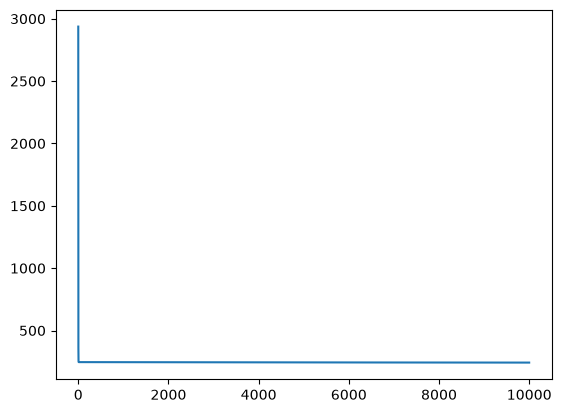

In [ ]:
loss_history = []
# 只会创建一个w和一个b,每个样本都用这一个
model = torch.nn.Linear(1, 1)
# 要求两参数维度一致，逐个元素计算(y_pred-y)^2并加起来,最后再求出均值
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.0001)
epochs = 10000
for epoch in range(epochs):
    pred = model(x1_train)  # 记录计算图
    loss = criterion(pred, y_train)  # 记录计算图
    optimizer.zero_grad()  # 只要在计算本轮梯度之前调用就没问题，用来清空上一轮的grad，
    # 若不清空，这一轮计算完梯度后梯度变成了这次的和上一次的总和，造成错误
    loss.backward()  # 计算梯度并保存到parameter.grad
    optimizer.step()  # 更新参数
    loss_history.append(loss.item())
plt.plot(loss_history)
print(loss_history[-1])

285.45238876342773


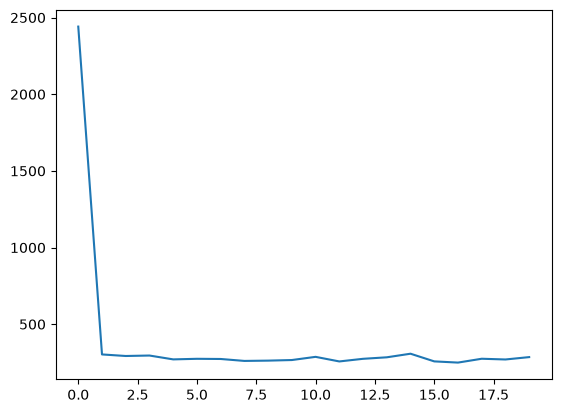

In [11]:
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(x1_train, y_train)
trainloader = DataLoader(dataset, 5, True)
model = torch.nn.Linear(1, 1)
# 重新定义model后optimizer也必须重新定义，把它绑定到现在model里面的参数，不然它只会去更新过去的参数
optimizer = torch.optim.SGD(model.parameters(), lr=0.0001)
epochs = 20
L = []
for _ in range(epochs):
    sum = 0
    for x, y in trainloader:
        pred = model(x)
        loss = criterion(pred, y)
        sum += loss.item() * len(x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    L.append(sum / len(x1_train))
plt.plot(L)
print(L[-1])

In [15]:
# 变为两个特征
x1_train = torch.cat([page_2024, word_2024], dim=1)
y_train = duration_2024
model = torch.nn.Linear(2, 1)
optimizer = torch.optim.SGD(model.parameters(), lr=0.0000001)
with torch.no_grad():
    # 这里W是1*2，到时候运算是X(batch_size*feature_num)*W的转置，所以就能把原X的第1维转为长度为1
    model.weight[0][0] = model.weight[0][1] = 1
    # bias.shape是(1,),也就是只有一个数，因为输出特征数为1，若输出特征数为5，则为(5,),到时候参与到矩阵加法的时候会发生广播,
    # 也就是每个样本都加一样的bias,毕竟每个样本所用参数完全相同，就是那一套
    model.bias[0] = 15

In [16]:
cur_loss = 0
epochs = 10000
for _ in range(epochs):
    pred = model(x1_train)
    loss = criterion(pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    cur_loss = loss.item()
print(cur_loss)

69.2299575805664


In [ ]:
x1_train = page_2021  # 函数输入
y_train = duration_2021  # 正确答案
# 用模型w2*x^2+w1*x+w0
w = torch.randn(3, requires_grad=True)  # 这样w就成了训练参数了，里面有参数.grad


def model(x):
    return w[2] * x**2 + w[1] * x + w[0]


lr = 0.0001
# 手动维护版本
for epoch in range(10000):
    pred = model(x1_train)
    loss = criterion(pred, y_train)
    loss.backward()
    with torch.no_grad():
        w -= lr * w.grad  # type: ignore 这里w的初始类型为None，只有backward后才有类型和值，所以这里静态分析器容易提示错误
    w.grad.zero_()  # type: ignore
# optimizer版本
# 这里用[w]的原因：
# optimizer初始化时需要一个参数列表，optimizer.step()大概是这样实现的
# for parameter in params:
#    parameter -= lr * parameter.grad
# 如果你传w，那么它得到的是w中的三个元素，不是独立的对象，也就没法调用.grad
optimizer = torch.optim.SGD([w], lr=lr)
for epoch in range(10000):
    pred = model(x1_train)
    loss = criterion(pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()